In [1]:
%pip install matplotlib numpy
%config IPCompleter.greedy=True

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np 
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = [12, 7.42]

In [3]:
L = 1
alpha = 0.01
Nx = 50
dx = L/Nx
dt_max = 0.02
r = 0.4
dt = r * dt_max
T0 = 1

In [4]:
def distribuzione_sin(T0: float, x: float, t: float, alpha: float, L: float) -> float:
    T_in = T0 * np.sin(np.pi * x / L)
    return T0 * np.exp(-alpha * np.pi**2 * t / L**2) * np.sin(np.pi * x / L)

xs = np.linspace(0, L, Nx+1)

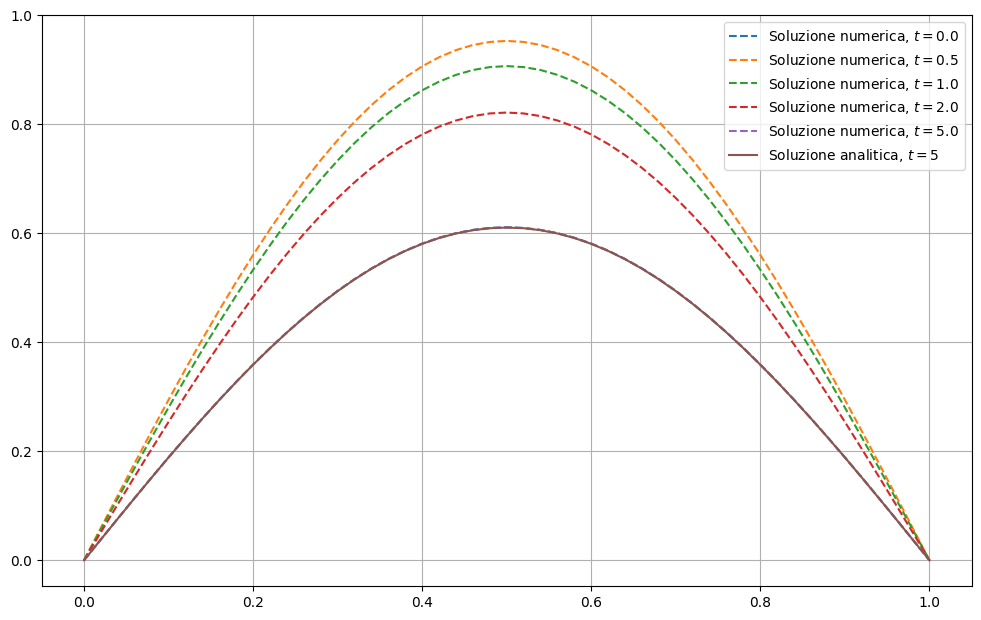

In [5]:
def ftcs(T0: float, Tl: float, Tr: float, x: list[float], t: float, dt: float, L: float, alpha: float, dx: float) -> list[float]:
    r = alpha * dt / (dx**2)
    steps = t / dt
    Ts = np.zeros((int(steps), len(x)))
    Ts[0,:] = T0 * np.sin(np.pi * x / L)
    Ts[:, 0], Ts[:, -1] = Tl, Tr
    
    for i in range(int(steps)-1):
        for j in range(1, len(xs)-1):
            Ts[i+1][j] = Ts[i][j] + r * (Ts[i][j+1] - 2*Ts[i][j] + Ts[i][j-1])
    return Ts

Ts = ftcs(T0=1, Tl=0, Tr=0, x=xs, t=5, dt=dt, L=L, alpha=alpha, dx=dx)

for i in [0.0, 0.5, 1.0, 2.0, 5.0]:
    riga = int(i/dt)
    plt.plot(xs, Ts[riga-1, :], "--", label=rf"Soluzione numerica, $t={i}$")

plt.plot(xs, distribuzione_sin(T0=T0, x=xs, t=5, alpha=alpha, L=L), label=r"Soluzione analitica, $t=5$")
plt.grid()
plt.legend()
plt.show()

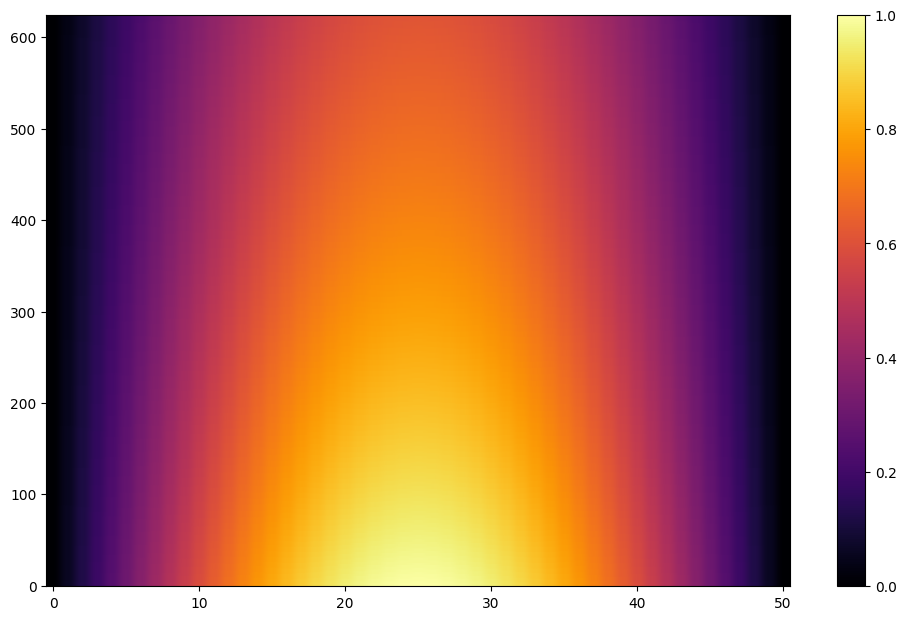

In [18]:
plt.imshow(Ts, aspect='auto', origin='lower', cmap="inferno")
plt.colorbar()
plt.show()

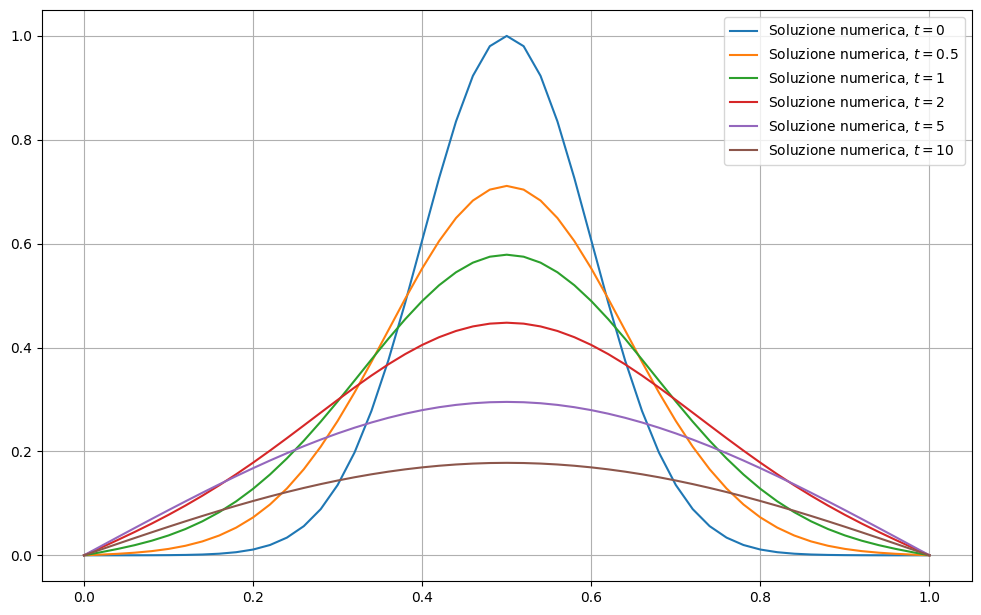

In [7]:
def ftcs1(T0: float, Tl: float, Tr: float, x: list[float], t: float, dt: float, L: float, alpha: float, dx: float) -> list[float]:
    r = alpha * dt / (dx**2)
    sigma = 0.1 * L
    steps = t / dt
    Ts = np.ones((int(steps), len(x)))
    Ts[0] = T0 * np.exp(-(x - L/2)**2 / (2 * sigma**2))
    
    for i in range(int(steps)-1):
        for j in range(1, len(xs)-1):
            Ts[i+1][j] = Ts[i][j] + r * (Ts[i][j+1] - 2*Ts[i][j] + Ts[i][j-1])
        Ts[i+1][0], Ts[i+1][-1] = Tl, Tr
    return Ts

Ts1 = ftcs1(T0=1, Tl=0, Tr=0, x=xs, t=10, dt=dt, L=L, alpha=alpha, dx=dx)

for i in [0, 0.5, 1, 2, 5, 10]:
    riga = int(i/dt)
    if riga == 0:
        plt.plot(xs, Ts1[riga, :], label=rf"Soluzione numerica, $t={i}$")
    else:
        plt.plot(xs, Ts1[riga-1, :], label=rf"Soluzione numerica, $t={i}$")

plt.grid()
plt.legend()
plt.show()

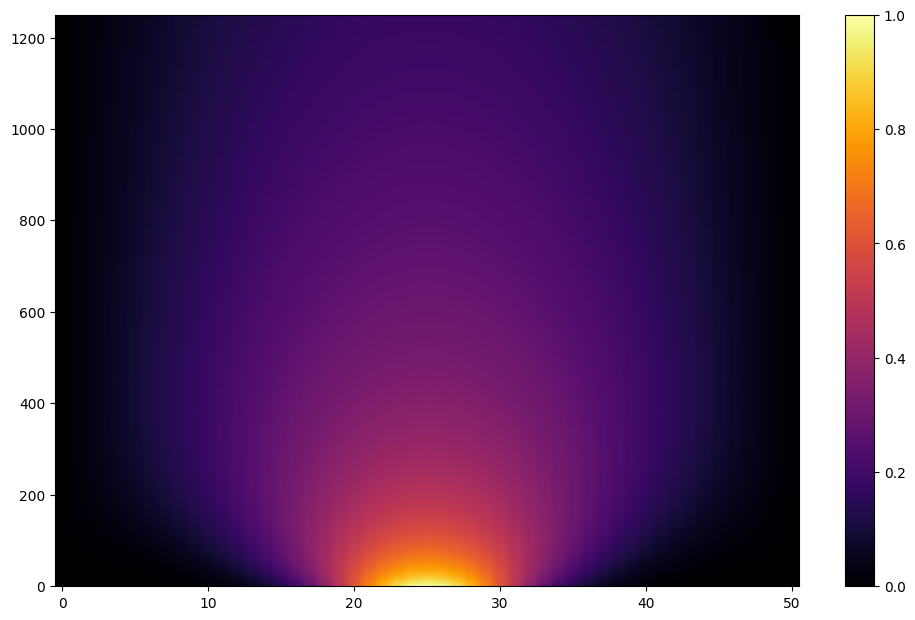

In [17]:
plt.imshow(Ts1, aspect='auto', origin='lower', cmap="inferno")
plt.colorbar()
plt.show()

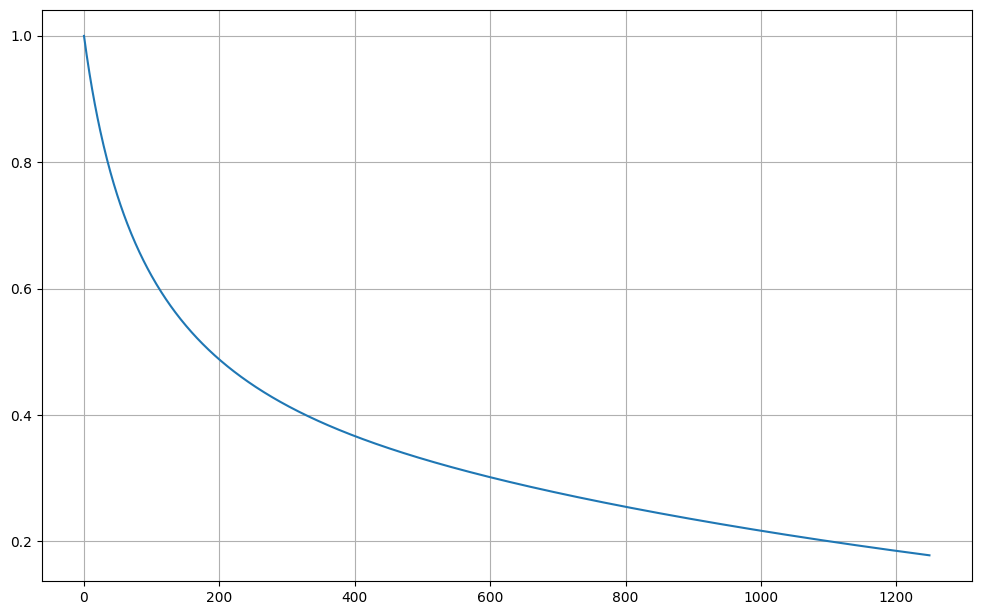

In [9]:
ts_max = []
for tst in Ts1:
    ts_max.append(max(tst))

plt.plot(ts_max)
plt.grid()
plt.show()

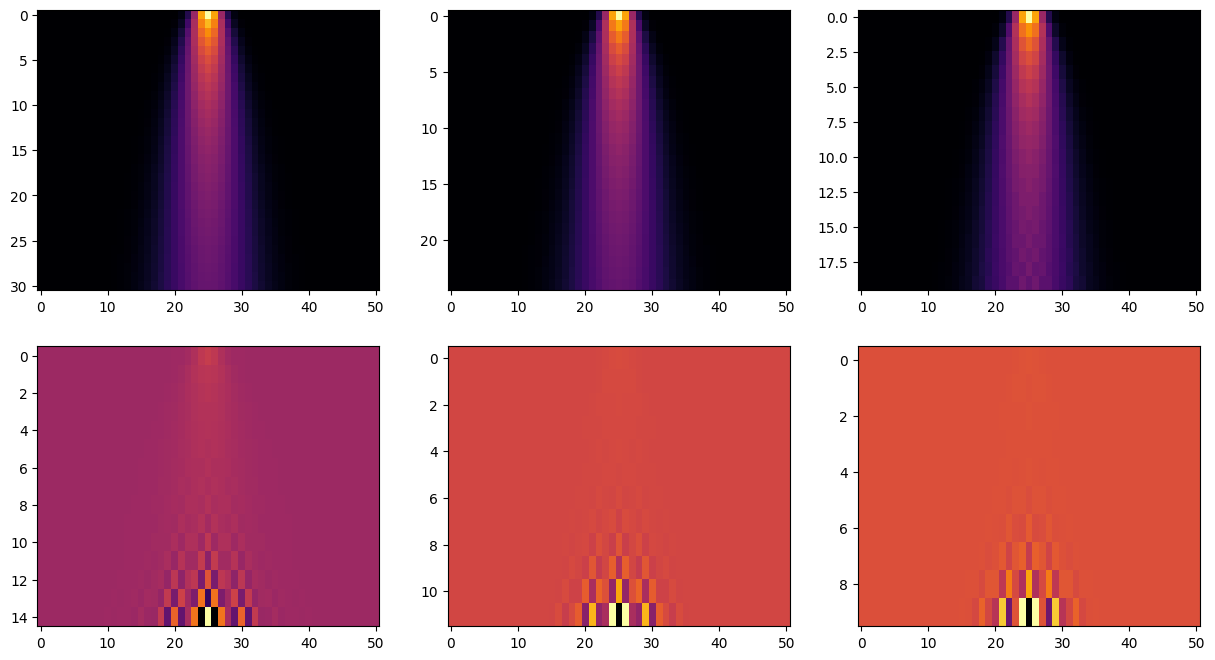

In [15]:
def ftcs2(T0: float, Tl: float, Tr: float, x: list[float], t: float, r: float, L: float, dx: float, alpha: float) -> list[float]:
    sigma = 0.03 * L
    dt = dx**2 * r / alpha
    steps = t / dt
    Ts = np.ones((int(steps), len(x)))
    Ts[0] = T0 * np.exp(-(x - L/2)**2 / (2 * sigma**2))
    
    for i in range(int(steps)-1):
        for j in range(1, len(xs)-1):
            Ts[i+1][j] = Ts[i][j] + r * (Ts[i][j+1] - 2*Ts[i][j] + Ts[i][j-1])
        Ts[i+1][0], Ts[i+1][-1] = Tl, Tr
    return Ts

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes[0,0].imshow(ftcs2(T0=T0, Tl=0, Tr=0, x=xs, t=0.5, r=0.4, L=L, dx=dx, alpha=alpha), aspect="auto", origin="upper", cmap="inferno")
axes[0,1].imshow(ftcs2(T0=T0, Tl=0, Tr=0, x=xs, t=0.5, r=0.5, L=L, dx=dx, alpha=alpha), aspect="auto", origin="upper", cmap="inferno")
axes[0,2].imshow(ftcs2(T0=T0, Tl=0, Tr=0, x=xs, t=0.5, r=0.6, L=L, dx=dx, alpha=alpha), aspect="auto", origin="upper", cmap="inferno")
axes[1,0].imshow(ftcs2(T0=T0, Tl=0, Tr=0, x=xs, t=0.5, r=0.8, L=L, dx=dx, alpha=alpha), aspect="auto", origin="upper", cmap="inferno")
axes[1,1].imshow(ftcs2(T0=T0, Tl=0, Tr=0, x=xs, t=0.5, r=1.0, L=L, dx=dx, alpha=alpha), aspect="auto", origin="upper", cmap="inferno")
axes[1,2].imshow(ftcs2(T0=T0, Tl=0, Tr=0, x=xs, t=0.5, r=1.2, L=L, dx=dx, alpha=alpha), aspect="auto", origin="upper", cmap="inferno")
plt.show()

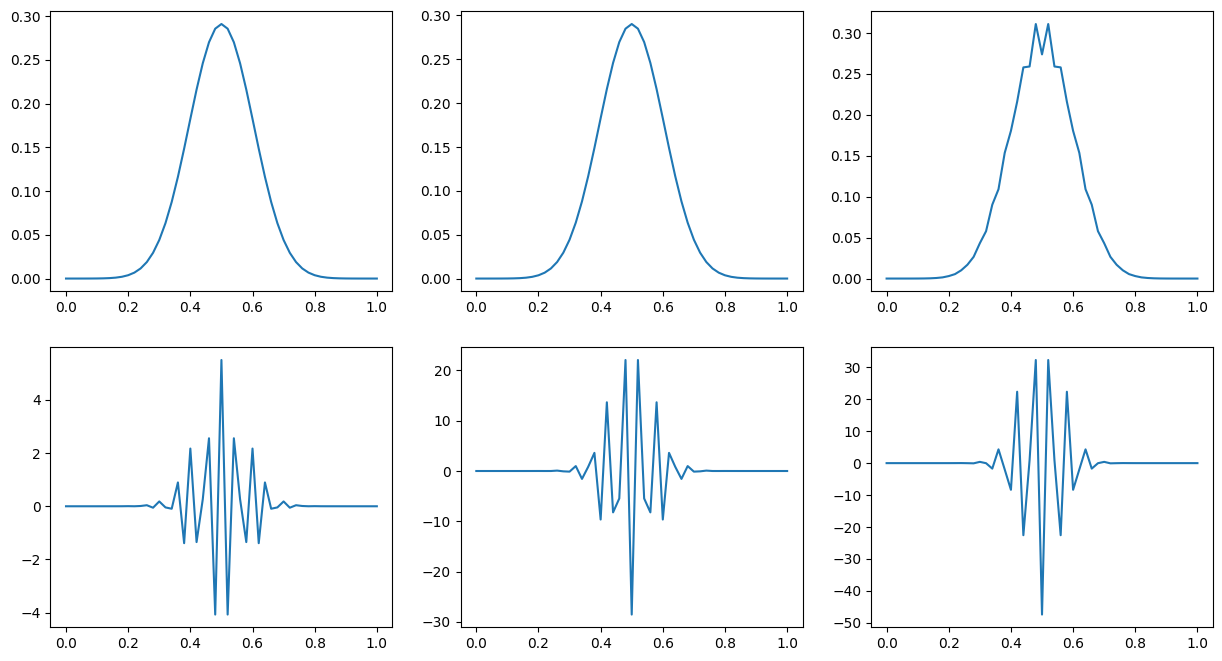

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes[0,0].plot(xs, ftcs2(T0=T0, Tl=0, Tr=0, x=xs, t=0.5, r=0.4, L=L, dx=dx, alpha=alpha)[-1, :], label="r=0.4")
axes[0,1].plot(xs, ftcs2(T0=T0, Tl=0, Tr=0, x=xs, t=0.5, r=0.5, L=L, dx=dx, alpha=alpha)[-1, :], label="r=0.5")
axes[0,2].plot(xs, ftcs2(T0=T0, Tl=0, Tr=0, x=xs, t=0.5, r=0.6, L=L, dx=dx, alpha=alpha)[-1, :], label="r=0.6")
axes[1,0].plot(xs, ftcs2(T0=T0, Tl=0, Tr=0, x=xs, t=0.5, r=0.8, L=L, dx=dx, alpha=alpha)[-1, :], label="r=0.8")
axes[1,1].plot(xs, ftcs2(T0=T0, Tl=0, Tr=0, x=xs, t=0.5, r=1.0, L=L, dx=dx, alpha=alpha)[-1, :], label="r=1.0")
axes[1,2].plot(xs, ftcs2(T0=T0, Tl=0, Tr=0, x=xs, t=0.5, r=1.2, L=L, dx=dx, alpha=alpha)[-1, :], label="r=1.2")
plt.show()